# 调度 Trace 时间线（traing.csv）

数据来自 tracing.hpp 导出的 `tid,seq,kind,t_us,cpu,tag`（client 退出时写 `./tmp/traing.csv`）。

- 键 = OS 线程号(tid);事件六类:`wake`(唤醒)/`release`(释放)/`execute`(执行)/`complete`(完成)/`finished`(整轮)/`sleep`(休眠)
- `cpu` = 事件时刻所在核心(worker 绑核应恒定;计时/主线程不绑,会迁移)
- `plot_trace` 画每线程事件时间线 + CPU 占用;`plot_trace_durations` 画 job 执行时长分布



In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [213]:
def plot_trace(csv, png=None, t_lim=None, tids=None, skip_idle=False, max_points=200_000):
    """读 trace CSV（tid,seq,kind,t_us,cpu,tag）画调度时间线。
    左：每线程一行的事件时间线（x=t_us→ms，颜色=事件类型）；
    右：每线程所在 CPU 随时间（核对绑核：worker 应恒一个 core）。
    大数据加速：
      - scatter 全 rasterized（位图渲染，100k+ 点不卡）；
      - skip_idle=True 丢 wake/sleep 空闲噪音（长跑每 ms 2 点，会糊掉时间线）；
      - 超过 max_points 自动均匀降采样。
    """
    df = pd.read_csv(csv)
    df["t_ms"] = df["t_us"] / 1000.0
    if skip_idle:
        df = df[~df["kind"].isin(["wake", "sleep"])]
    if t_lim is not None:
        df = df[(df["t_ms"] >= t_lim[0]) & (df["t_ms"] <= t_lim[1])]
    if tids is not None:
        df = df[df["tid"].isin(tids)]
    if len(df) > max_points:                       # 自动降采样（均匀抽）
        df = df.iloc[:: len(df) // max_points]
    if df.empty:
        print(f"[plot_trace] {csv}: empty after filter")
        return None
    tids_ = list(dict.fromkeys(df["tid"]))          # 去重保序
    tid2row = {t: i for i, t in enumerate(tids_)}
    df["row"] = df["tid"].map(tid2row)

    kind_colors = {
        "wake": "#bbbbbb", "release": "#1f77b4", "execute": "#2ca02c",
        "complete": "#ff7f0e", "finished": "#d62728", "sleep": "#555555",
        "main::expand": "#9467bd", "main::rollover": "#8c564b",
    }
    # main::expand/main::rollover 是主线程的不同阶段：按 tag 区分上色，不混进同一种 kind 颜色
    df["cat"] = np.where(df["tag"].isin(["main::expand", "main::rollover"]), df["tag"], df["kind"])
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(4, 1.1 * len(tids_))))

    for cat in df["cat"].unique():
        sub = df[df["cat"] == cat]
        ax1.scatter(sub["t_ms"], sub["row"], s=8, alpha=0.55,
                    color=kind_colors.get(cat, "black"), label=cat,
                    linewidths=0, rasterized=True)
    ax1.set_yticks(range(len(tids_)))
    ax1.set_yticklabels(tids_)
    ax1.set_xlabel("time (ms)")
    ax1.set_ylabel("thread (tid)")
    ax1.set_title(f"per-thread event timeline (n={len(df)})")
    ax1.legend(loc="upper right", fontsize=8, ncol=3)

    for tid in tids_:
        sub = df[df["tid"] == tid]
        ax2.scatter(sub["t_ms"], sub["cpu"], s=8, alpha=0.5, label=str(tid),
                    linewidths=0, rasterized=True)
    ax2.set_xlabel("time (ms)")
    ax2.set_ylabel("cpu core")
    ax2.set_title("cpu binding over time")
    ax2.legend(loc="upper right", fontsize=8)

    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight")
        print("saved:", png)
        plt.close(fig)
    return fig


def plot_trace_durations(csv, png=None, q=0.99):
    """worker cycle 时长分布：finished - release（worker 处理一个 job 的整轮，含 pack+algo+post）。
    只保留这一半（job exec execute->complete 不需要）。
    """
    df = pd.read_csv(csv)
    excl = {"timer", "main::expand", "main::rollover"}
    rows = []
    for tid, g in df.groupby("tid"):
        g = g.sort_values("seq")
        rl = g.loc[(g["kind"] == "release") & (~g["tag"].isin(excl)), "t_us"].values
        fn = g.loc[(g["kind"] == "finished") & (~g["tag"].isin(excl)), "t_us"].values
        n = min(len(rl), len(fn))
        if n:
            rows.append(fn[:n] - rl[:n])
    if not rows:
        print(f"[plot_trace_durations] {csv}: no pair-able events"); return None
    cycle = np.concatenate(rows)
    cycle = cycle[cycle > 0]
    cap = np.quantile(cycle, q)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(cycle[cycle <= cap], bins=60, color="steelblue", alpha=0.75)
    ax.set_xlabel("cycle us (finished - release)")
    ax.set_ylabel("count")
    ax.set_title(f"worker cycle distribution (P{q:.0%}, n={len(cycle)})")
    for lab, val in (("min", cycle.min()), ("mean", cycle.mean()),
                     ("p50", np.median(cycle)), ("p99", np.quantile(cycle, 0.99))):
        ax.axvline(val, color="crimson" if lab == "p99" else "0.4", lw=1, ls="--")
        ax.text(val, ax.get_ylim()[1] * 0.97, f" {lab}={val:.0f}", rotation=90,
                va="top", ha="center", fontsize=8, family="monospace")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig



# 额外开销 / 算法包装 风琴图

每算法一条**堆积条**（不分线程、剔除 main/timer）：

- `pack`   = execute − release   （取到 job → 开始执行：调度/分发 + 打包输入）
- `algo_us`= complete − execute  （算法实际执行）
- `route`  = finished − complete （执行完 → 整轮完成：路由输出）

`plot_overhead_accordion` 只画 pack + route 两段额外开销；`plot_algo_wrap_accordion`
画完整构成 pack + algo + route（算法被包装）。


In [214]:
def _job_segments(csv):
    """从 trace 提取每个 worker job 的三段耗时（µs），剔除 main/timer 线程。
    返回 DataFrame: algo(节点名), pack, algo_us, post。
    main/timer 判定：release/finished 的 tag 为 timer/main::expand/main::rollover 者剔除。
      pack   = execute − release   （取到 job → 开始执行：分发 + 打包输入 pack_inputs）
      algo_us= complete − execute  （算法实际执行）
      post   = finished − complete （执行完 → 整轮完成：record_exec + 路由输出 + 收尾）
    """
    df = pd.read_csv(csv)
    excl = {"timer", "main::expand", "main::rollover"}
    rows = []
    for tid, g in df.groupby("tid"):
        g = g.sort_values("seq")
        rl = g.loc[(g["kind"] == "release") & (~g["tag"].isin(excl)), ["tag", "t_us"]].values
        ex = g.loc[g["kind"] == "execute", ["tag", "t_us"]].values
        cp = g.loc[g["kind"] == "complete", ["tag", "t_us"]].values
        fn = g.loc[(g["kind"] == "finished") & (~g["tag"].isin(excl)), ["tag", "t_us"]].values
        n = min(len(rl), len(ex), len(cp), len(fn))
        for i in range(n):
            rows.append((tid, ex[i][0], ex[i][1] - rl[i][1], cp[i][1] - ex[i][1], fn[i][1] - cp[i][1]))
    return pd.DataFrame(rows, columns=["tid", "algo", "pack", "algo_us", "post"])


def _overhead_violin_style(ax, d, xcol, ycol, cats, cap_q=0.99):
    """原 notebook 风格：每类一把 violin（P99 截断）+ min→P99 range 线 + P99/mean/min 刻度标注。
    y 轴上限取各分类 P99 的最大值 ×1.15，保证 p99 标注 / range 线不超出图幅。
    """
    cap = d[ycol].quantile(cap_q)
    d_cut = d[d[ycol] <= cap]
    sns.violinplot(data=d_cut, x=xcol, y=ycol, hue=xcol, legend=False,
                   palette="Set2", cut=0, inner=None, linewidth=0, ax=ax)
    n = len(cats)
    ax.set_xlim(-0.4, n - 0.6)
    max_p99 = 0.0
    for xpos, c in enumerate(cats):
        sub = d.loc[d[xcol] == c, ycol]
        mn, mean, p99 = sub.min(), sub.mean(), sub.quantile(0.99)
        max_p99 = max(max_p99, p99)
        ax.plot([xpos, xpos], [mn, p99], color="0.35", lw=1.0)
        for val in (p99, mean, mn):
            ax.plot([xpos - 0.02, xpos + 0.02], [val, val], color="0.35", lw=1.2)
            ax.text(xpos + 0.09, val, f"{val:.1f}", ha="left", va="center",
                    fontsize=8, family="monospace")
    ax.set_ylim(0, max_p99 * 1.15)


def plot_overhead_violin(csv, png=None, q=0.99):
    """额外开销小提琴：pack / post 两把（原 notebook 风格）。不含 main/timer。"""
    d = _job_segments(csv)
    if d.empty:
        print(f"[plot_overhead_violin] {csv}: no worker jobs"); return None
    long = d.melt(value_vars=["pack", "post"], var_name="metric", value_name="us")
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6))
    _overhead_violin_style(ax, long, "metric", "us", ["pack", "post"], q)
    ax.set_ylabel("overhead us")
    ax.set_title(f"pack / post overhead distribution (P{q:.0%}, n={len(d)})")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig


def plot_total_overhead_violin(csv, png=None, q=0.99):
    """总开销(pack+post)单独一张：每算法一把总开销小提琴（原 notebook 风格）。"""
    d = _job_segments(csv)
    if d.empty:
        print(f"[plot_total_overhead_violin] {csv}: no worker jobs"); return None
    d = d.copy()
    d["overhead"] = d["pack"] + d["post"]
    algos = list(dict.fromkeys(d["algo"]))
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6))
    _overhead_violin_style(ax, d, "algo", "overhead", algos, q)
    ax.set_ylabel("overhead us (pack+post)")
    ax.set_title(f"per-algo total overhead distribution (P{q:.0%}, n={len(d)})")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig


def plot_total_overhead_stacked(csv, png=None, stat="mean"):
    """完整额外开销：pack + post 两个因素叠加。每算法一条堆叠横条，
    底 = pack，顶 = post，总长 = 完整额外开销(pack+post)。"""
    d = _job_segments(csv)
    if d.empty:
        print(f"[plot_total_overhead_stacked] {csv}: no worker jobs"); return None
    g = d.groupby("algo")[["pack", "post"]].agg(stat).reset_index()
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(g))))
    y = np.arange(len(g))
    ax.barh(y, g["pack"], label="pack", color="#1f77b4")
    ax.barh(y, g["post"], left=g["pack"], label="post", color="#ff7f0e")
    ax.set_yticks(y); ax.set_yticklabels(g["algo"])
    ax.set_xlabel(f"us ({stat})")
    ax.set_title(f"complete overhead = pack + post ({stat}, n={len(d)})")
    ax.legend(fontsize=8)
    for yi, (p, po) in enumerate(zip(g["pack"], g["post"])):
        ax.text(p + po, yi, f" {p:.0f}+{po:.0f}={p + po:.0f}", va="center", fontsize=8)
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig


def plot_algo_wrap_accordion(csv, png=None, stat="mean"):
    """算法重新包装：每算法一条堆积条 = [pack][algo][post]，
    算法执行被前后额外开销包裹的完整构成（total = finished - release）。"""
    d = _job_segments(csv)
    if d.empty:
        print(f"[plot_algo_wrap_accordion] {csv}: no worker jobs"); return None
    g = d.groupby("algo")[["pack", "algo_us", "post"]].agg(stat).reset_index()
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, max(3, 0.55 * len(g))))
    y = np.arange(len(g))
    ax.barh(y, g["pack"], label="pack", color="#1f77b4")
    ax.barh(y, g["algo_us"], left=g["pack"], label="algo", color="#2ca02c")
    ax.barh(y, g["post"], left=g["pack"] + g["algo_us"], label="post", color="#ff7f0e")
    ax.set_yticks(y); ax.set_yticklabels(g["algo"])
    ax.set_xlabel(f"us ({stat})")
    ax.set_title(f"per-algo cycle = pack + algo + post (excl main/timer, n={len(d)})")
    ax.legend(fontsize=8)
    for yi, (p, a, po) in enumerate(zip(g["pack"], g["algo_us"], g["post"])):
        ax.text(p + a + po, yi, f" {a:.0f}us(+{p + po:.0f})", va="center", fontsize=8)
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig



def _wake_cycle_overhead(csv):
    """总开销（不分类）：每个 worker job 的 (wake→sleep) − (execute→complete)。
    按线程事件序：wake 开周期、下一个 sleep 闭周期，周期内含 execute/complete 才算一个 job。
    """
    df = pd.read_csv(csv)
    excl = {"timer", "main::expand", "main::rollover"}
    out = []
    for tid, g in df.groupby("tid"):
        g = g.sort_values("seq")
        k = g["kind"].values
        t = g["t_us"].values
        wake_idx = np.where(k == "wake")[0]
        sleep_idx = np.where(k == "sleep")[0]
        ex_idx = np.where(k == "execute")[0]
        cp_idx = np.where(k == "complete")[0]
        for wi in wake_idx:
            j = np.searchsorted(sleep_idx, wi, side="right")
            if j >= len(sleep_idx):
                break
            sei = sleep_idx[j]
            ex_in = ex_idx[(ex_idx > wi) & (ex_idx < sei)]
            cp_in = cp_idx[(cp_idx > wi) & (cp_idx < sei)]
            if len(ex_in) and len(cp_in):
                oh = (t[sei] - t[wi]) - (t[cp_in[0]] - t[ex_in[0]])
                if oh > 0:
                    out.append(oh)
    return np.array(out)


def plot_total_extra_overhead(csv, png=None, q=0.99):
    """总额外开销（不分类）：(wake→sleep) − (execute→complete)，所有 worker job 汇总一把小提琴。"""
    oh = _wake_cycle_overhead(csv)
    if len(oh) == 0:
        print(f"[plot_total_extra_overhead] {csv}: no job cycles"); return None
    d = pd.DataFrame({"metric": "total", "us": oh})
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6))
    _overhead_violin_style(ax, d, "metric", "us", ["total"], q)
    ax.set_ylabel("overhead us (wake->sleep - algo)")
    ax.set_title(f"total extra overhead, not classified (P{q:.0%}, n={len(oh)})")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig


def plot_extra_overhead_by_thread(csv, png=None, q=0.99):
    """Per-thread overhead violin: (release->finished) - (execute->complete) = pack+post.
    x-axis tick labels carry tid/wid/core (rotated to fit), no legend box.
    """
    d = _job_segments(csv)
    if d.empty:
        print(f"[plot_extra_overhead_by_thread] {csv}: no worker jobs"); return None
    d = d.copy()
    d["overhead"] = d["pack"] + d["post"]
    tids = list(dict.fromkeys(d["tid"]))
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6))
    _overhead_violin_style(ax, d, "tid", "overhead", tids, q)
    ax.set_ylabel("overhead us (release->finished - algo)")
    ax.set_title(f"per-thread extra overhead (P{q:.0%}, n={len(d)})")

    # x tick labels = tid/core（wid=core−1 可推，不再标）；无 tid/w/c 前缀
    df = pd.read_csv(csv)
    core_of = df.groupby("tid")["cpu"].agg(lambda s: int(s.mode().iloc[0])).to_dict()
    labels = [f"{t}/{core_of.get(t, '?')}" for t in tids]
    ax.set_xticks(range(len(tids)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel("thread index / core index")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig


def plot_rollover_overhead(csv, png=None, q=0.99):
    """rollover 开销：main::rollover 的 release→finished。
    一张图左右两半：左 = 随 idx 时序散点；右 = 直方图 + min/mean/p50/p99/max 标注。
    """
    df = pd.read_csv(csv)
    r = df[df["tag"] == "main::rollover"].sort_values("seq")
    rl = r[r["kind"] == "release"]["t_us"].values
    fn = r[r["kind"] == "finished"]["t_us"].values
    n = min(len(rl), len(fn))
    us = fn[:n] - rl[:n]
    if n == 0:
        print(f"[plot_rollover_overhead] {csv}: no rollover events"); return None
    cap = np.quantile(us, q)
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.scatter(range(n), us, s=5, alpha=0.15, color="steelblue", linewidth=0)
    ax1.set_xlabel("rollover idx"); ax1.set_ylabel("us")
    ax1.set_title(f"rollover overhead over idx (n={n})")
    ax2.hist(us[us <= cap], bins=60, color="steelblue", alpha=0.7)
    ax2.set_xlabel("rollover overhead us"); ax2.set_ylabel("count")
    ax2.set_title(f"rollover overhead distribution (P{q:.0%})")
    for lab, val in (("min", us.min()), ("mean", us.mean()),
                     ("p50", np.median(us)), ("p99", np.quantile(us, 0.99)), ("max", us.max())):
        ax2.axvline(val, color="crimson" if lab in ("p99", "max") else "0.4", lw=1, ls="--")
        ax2.text(val, ax2.get_ylim()[1] * 0.97, f" {lab}={val:.0f}", rotation=90,
                 va="top", ha="center", fontsize=8, family="monospace")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight"); print("saved:", png); plt.close(fig)
    return fig









In [215]:
# ---- 四份 CSV 各画一张（路径按需改）----
base = ".."

saved: trace_timeline.png
saved: trace_durations.png


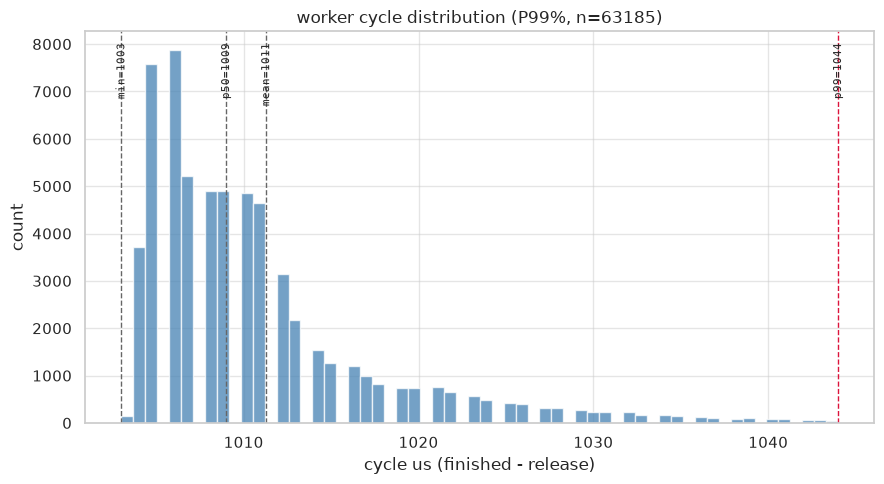

In [216]:
# ---- 新 trace（traing.csv）各画一张 ----
# skip_idle=True：长跑丢 wake/sleep 空闲噪音，时间线只留 job 事件；想看空闲段传 False
plot_trace(f"{base}/tmp/traing.csv", png="trace_timeline.png", skip_idle=True)
plot_trace_durations(f"{base}/tmp/traing.csv", png="trace_durations.png")


saved: total_extra_overhead.png
saved: overhead_by_algo.png
saved: overhead_by_thread.png
saved: rollover_overhead.png


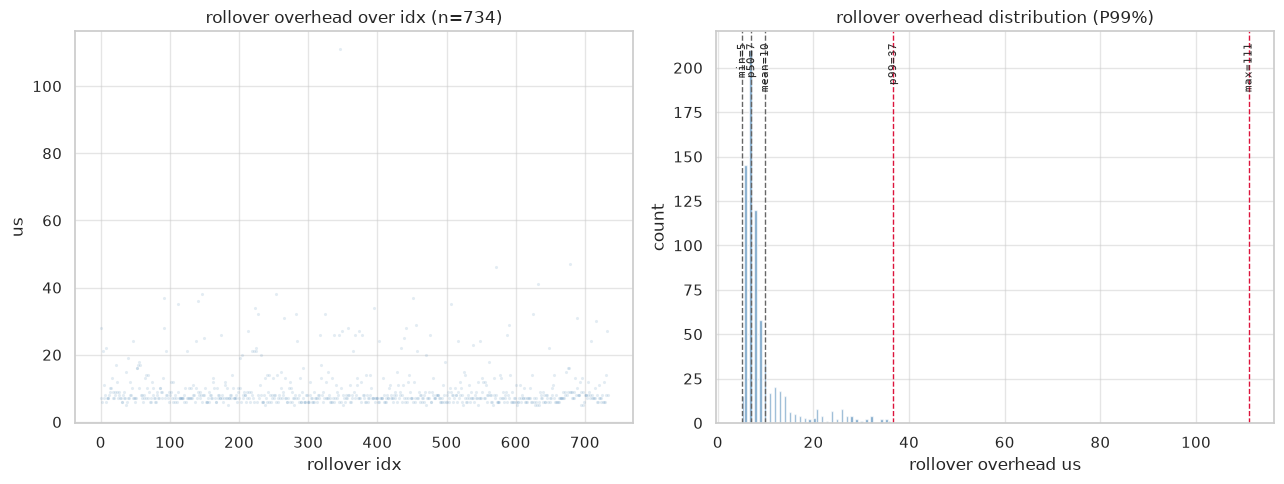

In [217]:
# ---- 额外开销 4 张图 ----
plot_total_extra_overhead(f"{base}/tmp/traing.csv", png="total_extra_overhead.png")      # 总开销(不分类)
plot_total_overhead_violin(f"{base}/tmp/traing.csv", png="overhead_by_algo.png")         # 按算法
plot_extra_overhead_by_thread(f"{base}/tmp/traing.csv", png="overhead_by_thread.png")    # 按线程
plot_rollover_overhead(f"{base}/tmp/traing.csv", png="rollover_overhead.png")            # rollover 散点+直方图
